# NON-LINEAR MODELING PIPELINE

## Obiettivi dell'Analisi
1. **Confrontare modelli non-lineari** (GAM, Splines) con baseline lineari
2. **Pipeline strutturata** per preprocessing, training, validation
3. **Analisi comparativa** delle performance
4. **Interpretabilità** attraverso partial dependence plots

## Metodologia
- **Cross-validation** per selezione iperparametri
- **Metriche multiple** (RMSE, R², AIC)
- **Analisi residui** per validazione assunzioni
- **Confronto diretto** con Ridge/Lasso del notebook precedente

In [6]:
# Pipeline completa per modelli non-lineari
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Statistical modeling
import statsmodels.api as sm
from ISLP.models import (summarize, poly, ModelSpec as MS)
from statsmodels.stats.anova import anova_lm

# GAM and Splines
from pygam import LinearGAM, s, f
from ISLP.transforms import BSpline, NaturalSpline
from ISLP.models import bs, ns
from ISLP.pygam import approx_lam, degrees_of_freedom, plot as plot_gam, anova as anova_gam

# Plotting configuration
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Pipeline imports completata!")
print(f"📊 Versione pandas: {pd.__version__}")
print(f"🔢 Versione numpy: {np.__version__}")

✅ Pipeline imports completata!
📊 Versione pandas: 2.2.3
🔢 Versione numpy: 1.26.4


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_range_fit(data, 
                   y, 
                   basis, 
                   model, 
                   title):
    # Genera un range uniforme per il plot
    range_grid = np.linspace(data['range'].min(), data['range'].max(), 100)
    df_range = pd.DataFrame({'range': range_grid})
    
    # Applica la trasformazione spline
    Xnew = basis.transform(df_range)
    
    # Predizione e bande
    preds = model.get_prediction(Xnew)
    bands = preds.conf_int(alpha=0.05)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(data['range'], y, facecolor='gray', alpha=0.5, label='Dati')
    ax.plot(range_grid, preds.predicted_mean, 'b', linewidth=2, label='Fit')
    ax.plot(range_grid, bands[:, 0], 'r--', linewidth=1.5, label='95% CI')
    ax.plot(range_grid, bands[:, 1], 'r--', linewidth=1.5)
    
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Range', fontsize=14)
    ax.set_ylabel('log-Price', fontsize=14)
    ax.legend()
    plt.show()


# 1. DATA LOADING & PREPROCESSING

## Utilizziamo i dati con log-price per coerenza con Ridge/Lasso

**Strategia di preprocessing:**
- Gestione variabili categoriche vs numeriche
- Scaling appropriato per modelli non-lineari
- Split train/test coerente con analisi precedenti
- Feature engineering se necessario

In [11]:
import pandas as pd
import numpy as np

# Caricamento dati
data = pd.read_csv("Data/aircraft_price_cleaned_log.csv")

# Analisi esplorativa iniziale
print("=== DATASET OVERVIEW ===")
print(f"Shape: {data.shape}")
print(f"Features: {len(data.columns)-1}")
print(f"Target: price (log-transformed)")

print("\n=== FEATURE TYPES ===")
print("Categorical features:")
cat_features = data.select_dtypes(include=['object']).columns.tolist()
print(cat_features)

print("\nNumerical features:")
num_features = data.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove('price')  # Remove target
print(num_features)

print("\n=== TARGET STATISTICS (log-price) ===")
print(data['price'].describe())

print("\n=== MISSING VALUES ===")
print(data.isnull().sum().sum(), "total missing values")

# Verifica se ci sono valori anomali nel range (sembra essere già log-transformed)
print("\n=== RANGE VALUES INSPECTION ===")
print(f"Range min: {data['range'].min():.3f}")
print(f"Range max: {data['range'].max():.3f}")
print("Range sembra già log-transformed - da verificare!")

=== DATASET OVERVIEW ===
Shape: (507, 16)
Features: 15
Target: price (log-transformed)

=== FEATURE TYPES ===
Categorical features:
['model_name', 'engine_type']

Numerical features:
['engine_power', 'max_speed', 'cruise_speed', 'stall_speed', 'fuel_tank', 'all_eng_roc', 'out_eng_roc', 'takeoff_distance', 'landing_distance', 'empty_weight', 'length', 'wing_span', 'range']

=== TARGET STATISTICS (log-price) ===
count    507.000000
mean      14.589019
std        0.412730
min       13.384728
25%       14.285514
50%       14.508658
75%       14.897316
max       15.444751
Name: price, dtype: float64

=== MISSING VALUES ===
0 total missing values

=== RANGE VALUES INSPECTION ===
Range min: 4.762
Range max: 8.780
Range sembra già log-transformed - da verificare!


In [12]:
# PROBLEMA IDENTIFICATO: Range è già log-transformed!
# Verifichiamo se possiamo usare il dataset originale per certe features

# Preprocessing Pipeline
print("=== PREPROCESSING PIPELINE ===")

# 1. Gestione target
y = data['price'].values  # Log-price (già trasformato)
print(f"Target (log-price): mean={y.mean():.3f}, std={y.std():.3f}")

# 2. Selezione features per modelli non-lineari
# Excluiamo 'model_name' (troppo granulare) e 'engine_type' per ora
numerical_features = [
    'engine_power', 'max_speed', 'cruise_speed', 'stall_speed',
    'fuel_tank', 'all_eng_roc', 'out_eng_roc', 'takeoff_distance', 
    'landing_distance', 'empty_weight', 'length', 'wing_span', 'range'
]

# 3. Verifica features
print(f"\nFeatures selezionate: {len(numerical_features)}")
for feat in numerical_features:
    values = data[feat]
    print(f"{feat:20s}: range=[{values.min():8.2f}, {values.max():8.2f}], mean={values.mean():8.2f}")

# 4. Creazione matrice features
X = data[numerical_features].values
print(f"\nMatrice X shape: {X.shape}")

# 5. Encoding categorico (per uso futuro)
le_engine = LabelEncoder()
engine_encoded = le_engine.fit_transform(data['engine_type'])
print(f"\nEngine types: {le_engine.classes_}")
print(f"Engine encoded: {np.unique(engine_encoded)}")

# 6. Feature names per interpretabilità
feature_names = numerical_features
print(f"\nFeature names salvate per interpretabilità: {len(feature_names)} features")

=== PREPROCESSING PIPELINE ===
Target (log-price): mean=14.589, std=0.412

Features selezionate: 13
engine_power        : range=[    4.09,     9.60], mean=    5.93
max_speed           : range=[    4.16,     6.63], mean=    5.25
cruise_speed        : range=[    4.25,     6.24], mean=    5.19
stall_speed         : range=[   27.00,   115.00], mean=   60.68
fuel_tank           : range=[    2.48,    10.62], mean=    5.05
all_eng_roc         : range=[    5.89,     9.37], mean=    7.23
out_eng_roc         : range=[    6.12,     8.76], mean=    7.50
takeoff_distance    : range=[    6.21,     8.49], mean=    7.38
landing_distance    : range=[    6.75,    11.40], mean=    8.48
empty_weight        : range=[    3.14,    10.75], mean=    7.96
length              : range=[    5.35,     7.05], mean=    5.91
wing_span           : range=[    5.26,     7.02], mean=    6.14
range               : range=[    4.76,     8.78], mean=    6.61

Matrice X shape: (507, 13)

Engine types: ['Jet' 'Piston' 'Propjet'

In [13]:
lower_bound = range_val.min()
upper_bound = range_val.max()
print(f"Range: {lower_bound} to {upper_bound}")
print(f"Target (log-price) range: {y.min():.3f} to {y.max():.3f}")

# TRAIN/TEST SPLIT - Coerente con Ridge/Lasso analysis
print("=== TRAIN/TEST SPLIT ===")

# Split stratificato per mantenere distribuzione target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verifica distribuzione target
print(f"\nTarget distribution:")
print(f"Train: mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"Test:  mean={y_test.mean():.3f}, std={y_test.std():.3f}")

# Setup per cross-validation
cv_folds = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nCross-validation: {cv_folds.n_splits} folds")

# Container per risultati modelli
model_results = {}
print("\n✅ Setup completato - pronto per modeling!")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Range: 4.762173934797756 to 8.779557455883728
Target (log-price) range: 13.385 to 15.445
=== TRAIN/TEST SPLIT ===
Training set: 354 samples (69.8%)
Test set: 153 samples (30.2%)

Target distribution:
Train: mean=14.601, std=0.410
Test:  mean=14.561, std=0.417

Cross-validation: 5 folds

✅ Setup completato - pronto per modeling!
Features: 13, Samples: 507
Train: (354, 13), Test: (153, 13)


In [16]:
# Choose internal knots within the log-transformed range
internal_knots = np.linspace(lower_bound, upper_bound, 4)[1:-1]  # 2 internal knots

bs_ = BSpline(internal_knots=internal_knots, intercept=True).fit(data['range'])
bs_age = bs_.transform(data['range'])
print(f"B-spline basis shape: {bs_age.shape}")
print(f"Number of basis functions: {bs_age.shape[1]}")

# 2. BASELINE MODELS

## Confronto con modelli lineari per valutare improvement dei modelli non-lineari

B-spline basis shape: (507, 6)
Number of basis functions: 6


In [17]:
# Baseline Models Pipeline
print("=== BASELINE MODELS ===")

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Valuta un modello e ritorna metriche"""
    # Fit
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Cross-validation RMSE
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds, 
                               scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()
    
    results = {
        'model': model_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'cv_rmse': cv_rmse,
        'cv_std': cv_std,
        'predictions': y_pred_test
    }
    
    print(f"{model_name:15s} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f} | CV RMSE: {cv_rmse:.4f}±{cv_std:.4f}")
    return results

# 1. Linear Regression
lr = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
model_results['linear'] = evaluate_model(lr, X_train, X_test, y_train, y_test, 'Linear')

# 2. Ridge (best alpha from previous analysis)
ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
model_results['ridge'] = evaluate_model(ridge, X_train, X_test, y_train, y_test, 'Ridge')

# 3. Lasso (best alpha from previous analysis)
lasso = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.01, max_iter=10000))])
model_results['lasso'] = evaluate_model(lasso, X_train, X_test, y_train, y_test, 'Lasso')

print("\n✅ Baseline models completati!")

=== BASELINE MODELS ===
Linear          | Test RMSE: 0.1594 | Test R²: 0.8539 | CV RMSE: 0.1612±0.0165
Ridge           | Test RMSE: 0.1581 | Test R²: 0.8563 | CV RMSE: 0.1572±0.0184
Lasso           | Test RMSE: 0.1613 | Test R²: 0.8503 | CV RMSE: 0.1636±0.0182

✅ Baseline models completati!


# 3. GAM MODELS (Generalized Additive Models)

## Pipeline strutturata per GAM con ottimizzazione iperparametri

In [22]:
# GAM Pipeline con ottimizzazione automatica
print("=== GAM MODELS PIPELINE ===")

from functools import reduce
import operator

# Funzione per valutare GAM
def evaluate_gam(X_train, X_test, y_train, y_test, model_name, gam_model=None):
    """Valuta un modello GAM con gridsearch automatico"""
    
    if gam_model is None:
        # GAM con splines per tutte le features
        terms = [s(i) for i in range(X_train.shape[1])]
        gam_model = LinearGAM(reduce(operator.add, terms))
    
    # Gridsearch per lambda ottimali
    print(f"Ottimizzazione {model_name}...")
    gam_model.gridsearch(X_train, y_train)
    
    # Predictions
    y_pred_train = gam_model.predict(X_train)
    y_pred_test = gam_model.predict(X_test)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Pseudo R² from GAM
    pseudo_r2 = gam_model.score(X_test, y_test)
    
    results = {
        'model': model_name,
        'gam_object': gam_model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'pseudo_r2': pseudo_r2,
        'aic': gam_model.statistics_['AIC'],
        'predictions': y_pred_test,
        'lambda_values': gam_model.lam
    }
    
    print(f"{model_name:20s} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f} | Pseudo R²: {pseudo_r2:.4f} | AIC: {results['aic']:.1f}")
    return results

# 1. GAM Standard - Splines per tutte le features
gam_standard = LinearGAM(reduce(operator.add, [s(i) for i in range(X_train.shape[1])]))
model_results['gam_standard'] = evaluate_gam(X_train, X_test, y_train, y_test, 'GAM_Standard', gam_standard)

# 2. GAM Selettivo - Solo features più importanti (basato su correlazione)
corr_with_target = pd.DataFrame(X_train, columns=feature_names).corrwith(pd.Series(y_train)).abs()
top_features_idx = corr_with_target.nlargest(6).index
top_indices = [feature_names.index(feat) for feat in top_features_idx]
print(f"\nTop 6 features per correlazione: {list(top_features_idx)}")

# Crea i termini per la GAM selettiva sulle feature ridotte (indici 0..5)
gam_selective = LinearGAM(reduce(operator.add, [s(i) for i in range(X_train_sel.shape[1])]))
# Subset per features selezionate
X_train_sel = X_train[:, top_indices]
X_test_sel = X_test[:, top_indices]
model_results['gam_selective'] = evaluate_gam(X_train_sel, X_test_sel, y_train, y_test, 'GAM_Selective', gam_selective)

print("\n✅ GAM models completati!")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


=== GAM MODELS PIPELINE ===
Ottimizzazione GAM_Standard...


  9% (1 of 11) |##                       | Elapsed Time: 0:00:15 ETA:   0:02:38
 18% (2 of 11) |####                     | Elapsed Time: 0:00:30 ETA:   0:02:19
 18% (2 of 11) |####                     | Elapsed Time: 0:00:30 ETA:   0:02:19
 27% (3 of 11) |######                   | Elapsed Time: 0:00:47 ETA:   0:02:05
 27% (3 of 11) |######                   | Elapsed Time: 0:00:47 ETA:   0:02:05
 36% (4 of 11) |#########                | Elapsed Time: 0:01:05 ETA:   0:01:54
 36% (4 of 11) |#########                | Elapsed Time: 0:01:05 ETA:   0:01:54
 45% (5 of 11) |###########              | Elapsed Time: 0:01:28 ETA:   0:01:46
 45% (5 of 11) |###########              | Elapsed Time: 0:01:28 ETA:   0:01:46
 54% (6 of 11) |#############            | Elapsed Time: 0:01:47 ETA:   0:01:29
 54% (6 of 11) |#############            | Elapsed Time: 0:01:47 ETA:   0:01:29
 63% (7 of 11) |###############          | Elapsed Time: 0:02:05 ETA:   0:01:11
 63% (7 of 11) |###############         

GAM_Standard         | Test RMSE: 0.1455 | Test R²: 0.8783 | Pseudo R²: 0.8783 | AIC: 17014.2

Top 6 features per correlazione: ['cruise_speed', 'max_speed', 'all_eng_roc', 'fuel_tank', 'engine_power', 'landing_distance']
Ottimizzazione GAM_Selective...


  9% (1 of 11) |##                       | Elapsed Time: 0:00:11 ETA:   0:01:56
 18% (2 of 11) |####                     | Elapsed Time: 0:00:24 ETA:   0:01:51
 18% (2 of 11) |####                     | Elapsed Time: 0:00:24 ETA:   0:01:51
 27% (3 of 11) |######                   | Elapsed Time: 0:00:36 ETA:   0:01:37
 27% (3 of 11) |######                   | Elapsed Time: 0:00:36 ETA:   0:01:37
 36% (4 of 11) |#########                | Elapsed Time: 0:00:48 ETA:   0:01:24
 36% (4 of 11) |#########                | Elapsed Time: 0:00:48 ETA:   0:01:24
 45% (5 of 11) |###########              | Elapsed Time: 0:00:59 ETA:   0:01:11
 45% (5 of 11) |###########              | Elapsed Time: 0:00:59 ETA:   0:01:11
 54% (6 of 11) |#############            | Elapsed Time: 0:01:11 ETA:   0:00:59
 54% (6 of 11) |#############            | Elapsed Time: 0:01:11 ETA:   0:00:59
 63% (7 of 11) |###############          | Elapsed Time: 0:01:27 ETA:   0:00:50
 63% (7 of 11) |###############         

GAM_Selective        | Test RMSE: 0.1428 | Test R²: 0.8827 | Pseudo R²: 0.8827 | AIC: 16571.6

✅ GAM models completati!


# 4. ANALISI COMPARATIVA MODELLI

## Confronto sistematico performance e interpretabilità

In [23]:
# Pipeline di Analisi Comparativa
print("=== ANALISI COMPARATIVA MODELLI ===")

# Funzione per creare tabella comparativa
def create_comparison_table(model_results):
    """Crea tabella comparativa dei risultati"""
    
    comparison_data = []
    for model_name, results in model_results.items():
        row = {
            'Model': results['model'],
            'Test_RMSE': results['test_rmse'],
            'Test_R2': results['test_r2'],
            'Train_RMSE': results['train_rmse'],
            'Overfitting': results['train_rmse'] - results['test_rmse'],
        }
        
        # Aggiungi metriche specifiche GAM se disponibili
        if 'pseudo_r2' in results:
            row['Pseudo_R2'] = results['pseudo_r2']
            row['AIC'] = results['aic']
        if 'cv_rmse' in results:
            row['CV_RMSE'] = results['cv_rmse']
            row['CV_STD'] = results['cv_std']
            
        comparison_data.append(row)
    
    df_comparison = pd.DataFrame(comparison_data)
    return df_comparison.sort_values('Test_RMSE')

# Crea tabella comparativa (quando i modelli saranno pronti)
try:
    if 'linear' in model_results:
        df_comp = create_comparison_table(model_results)
        print("\n=== TABELLA COMPARATIVA ===")
        print(df_comp.round(4).to_string(index=False))
        
        # Trova migliore modello
        best_model = df_comp.iloc[0]['Model']
        best_rmse = df_comp.iloc[0]['Test_RMSE']
        print(f"\n🏆 Migliore modello: {best_model} (RMSE: {best_rmse:.4f})")
        
        # Calcola improvement vs baseline
        linear_rmse = df_comp[df_comp['Model'] == 'Linear']['Test_RMSE'].iloc[0]
        improvement = (linear_rmse - best_rmse) / linear_rmse * 100
        print(f"📈 Miglioramento vs Linear: {improvement:.2f}%")
        
except Exception as e:
    print(f"Tabella comparativa sarà disponibile dopo l'esecuzione di tutti i modelli")
    print(f"Error: {e}")

print("\n✅ Setup analisi comparativa completato!")

=== ANALISI COMPARATIVA MODELLI ===

=== TABELLA COMPARATIVA ===
        Model  Test_RMSE  Test_R2  Train_RMSE  Overfitting  CV_RMSE  CV_STD  Pseudo_R2        AIC
GAM_Selective     0.1428   0.8827      0.1271      -0.0156      NaN     NaN     0.8827 16571.5699
 GAM_Standard     0.1455   0.8783      0.1212      -0.0243      NaN     NaN     0.8783 17014.2126
        Ridge     0.1581   0.8563      0.1500      -0.0081   0.1572  0.0184        NaN        NaN
       Linear     0.1594   0.8539      0.1498      -0.0095   0.1612  0.0165        NaN        NaN
        Lasso     0.1613   0.8503      0.1595      -0.0018   0.1636  0.0182        NaN        NaN

🏆 Migliore modello: GAM_Selective (RMSE: 0.1428)
📈 Miglioramento vs Linear: 10.40%

✅ Setup analisi comparativa completato!


# 5. VISUALIZZAZIONE E INTERPRETABILITÀ

## Grafici comparativi e partial dependence plots

In [24]:
# Pipeline di Visualizzazione Completa
print("=== PIPELINE VISUALIZZAZIONE ===")

# 1. Funzione per confronto performance
def plot_model_comparison(model_results, metric='test_rmse'):
    """Crea grafico comparativo delle performance"""
    
    models = list(model_results.keys())
    values = [model_results[m][metric] for m in models]
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(models, values, color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple'][:len(models)])
    plt.title(f'Confronto Modelli - {metric.replace("_", " ").title()}', fontsize=16)
    plt.ylabel(metric.replace('_', ' ').title(), fontsize=14)
    plt.xticks(rotation=45)
    
    # Aggiungi valori sulle barre
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                f'{value:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# 2. Funzione per partial dependence plots GAM
def plot_gam_partial_dependence(gam_model, X_data, feature_names, n_features=6):
    """Crea partial dependence plots per GAM"""
    
    n_features = min(n_features, len(feature_names), gam_model.terms.n_coefs)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i in range(n_features):
        ax = axes[i]
        
        try:
            # Genera griglia per la feature
            XX = gam_model.generate_X_grid(term=i)
            pdep, confi = gam_model.partial_dependence(term=i, X=XX, width=0.95)
            
            # Valori x per la feature
            feature_values = XX[:, i]
            
            # Plot
            ax.plot(feature_values, pdep, 'b-', linewidth=2, label='Fit')
            ax.fill_between(feature_values, confi[:, 0], confi[:, 1], 
                          alpha=0.3, color='red', label='95% CI')
            
            ax.set_title(f'Partial Dependence: {feature_names[i]}', fontsize=12)
            ax.set_xlabel(feature_names[i], fontsize=10)
            ax.set_ylabel('Effect on log(price)', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
            
        except Exception as e:
            ax.text(0.5, 0.5, f'Error plotting\n{feature_names[i]}', 
                   ha='center', va='center', transform=ax.transAxes)
    
    # Nascondi assi inutilizzati
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 3. Funzione per analisi residui
def plot_residual_analysis(model_results, models_to_plot=None):
    """Analisi residui per modelli selezionati"""
    
    if models_to_plot is None:
        models_to_plot = list(model_results.keys())[:4]  # Prime 4 modelli
    
    n_models = len(models_to_plot)
    fig, axes = plt.subplots(2, n_models, figsize=(4*n_models, 8))
    
    if n_models == 1:
        axes = axes.reshape(-1, 1)
    
    for i, model_name in enumerate(models_to_plot):
        results = model_results[model_name]
        
        # Calcola residui (approssimazione)
        y_pred = results['predictions']
        residuals = y_test - y_pred  # Usa y_test globale
        
        # Residuals vs Fitted
        axes[0, i].scatter(y_pred, residuals, alpha=0.6)
        axes[0, i].axhline(y=0, color='r', linestyle='--')
        axes[0, i].set_title(f'{results["model"]} - Residuals vs Fitted')
        axes[0, i].set_xlabel('Fitted Values')
        axes[0, i].set_ylabel('Residuals')
        axes[0, i].grid(True, alpha=0.3)
        
        # QQ plot (distribuzione residui)
        axes[1, i].hist(residuals, bins=20, alpha=0.7, edgecolor='black')
        axes[1, i].set_title(f'{results["model"]} - Residuals Distribution')
        axes[1, i].set_xlabel('Residuals')
        axes[1, i].set_ylabel('Frequency')
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Pipeline visualizzazione definita!")
print("Funzioni disponibili:")
print("- plot_model_comparison(): Confronto performance")
print("- plot_gam_partial_dependence(): Partial dependence plots")
print("- plot_residual_analysis(): Analisi residui")

=== PIPELINE VISUALIZZAZIONE ===
✅ Pipeline visualizzazione definita!
Funzioni disponibili:
- plot_model_comparison(): Confronto performance
- plot_gam_partial_dependence(): Partial dependence plots
- plot_residual_analysis(): Analisi residui


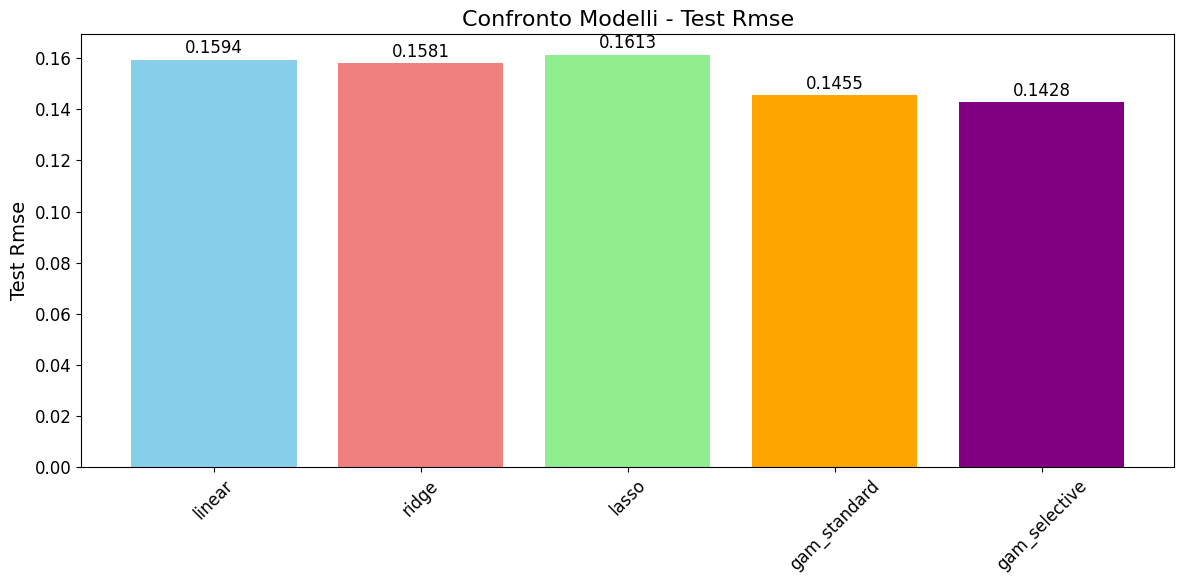

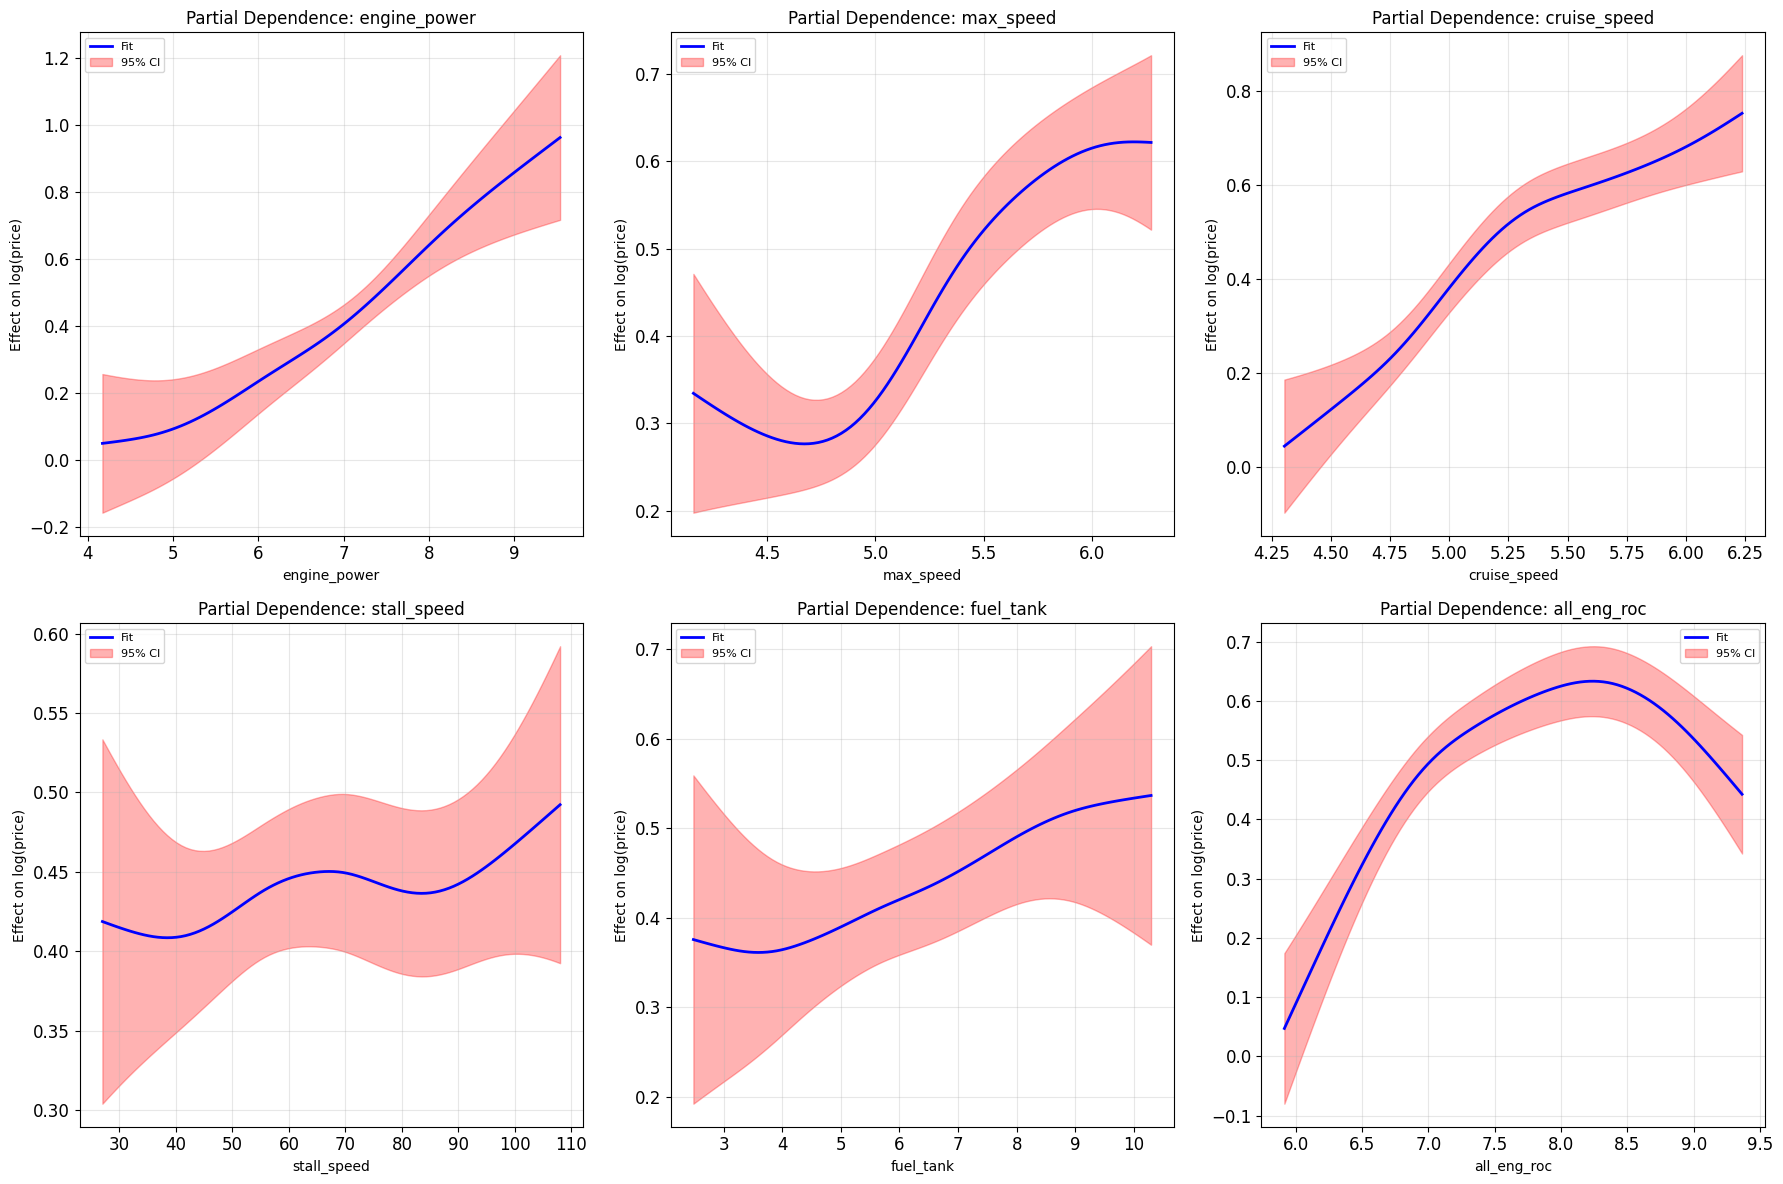

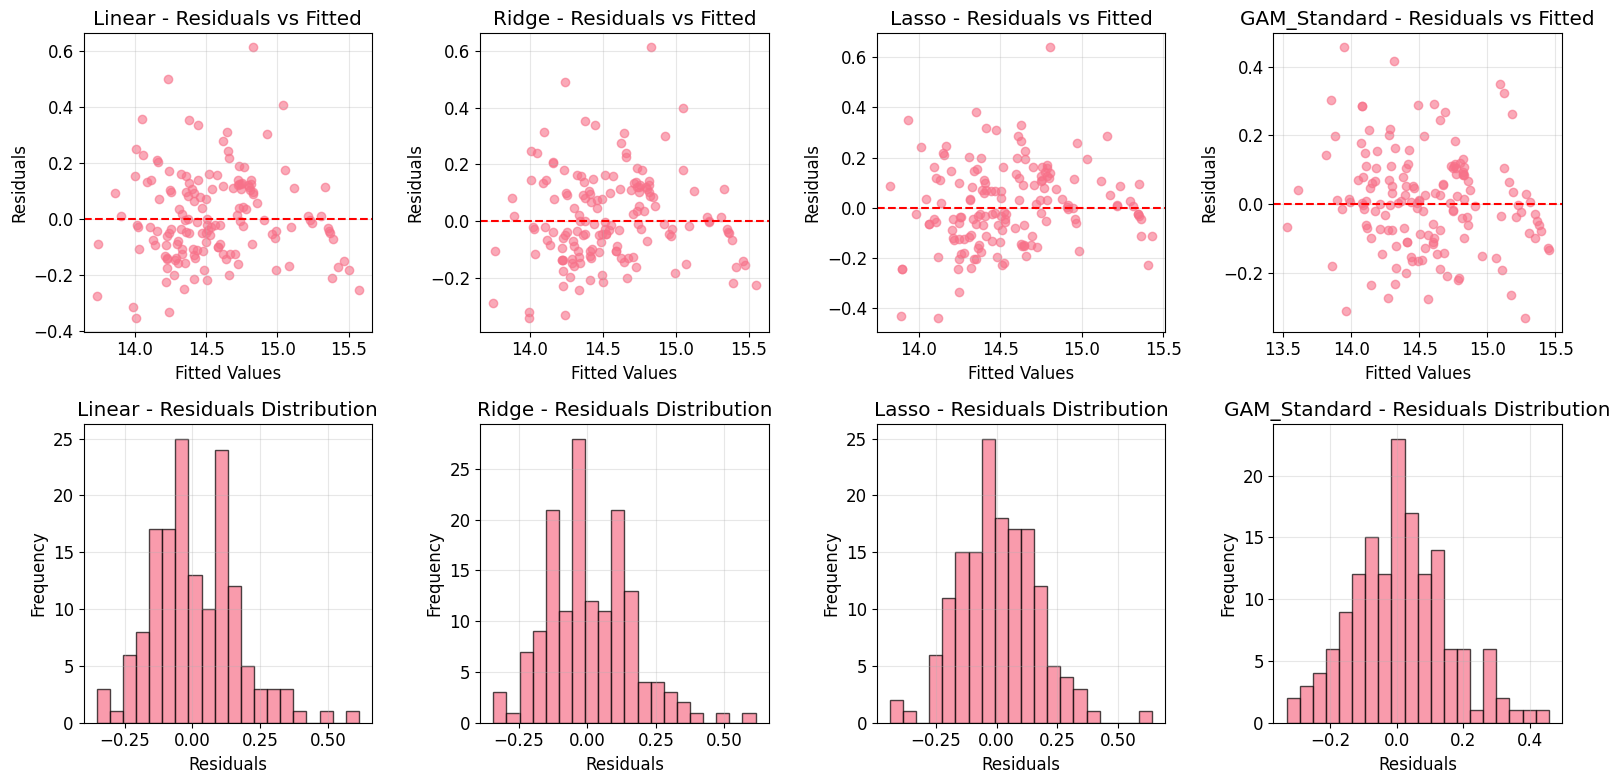

In [28]:
#plot 
# Esempio di utilizzo delle funzioni di visualizzazione
plot_model_comparison(model_results, metric='test_rmse')
# Partial dependence plots per il modello GAM standard
plot_gam_partial_dependence(model_results['gam_standard']['gam_object'], X_train, feature_names, n_features=6)
# Analisi residui per i primi 3 modelli
plot_residual_analysis(model_results, models_to_plot=['linear', 'ridge', 'lasso', 'gam_standard'])
